# DreamGuard — Maze Generator

Generates a randomised maze for each room, sized to fit the room dimensions read from
`docs/assets/DungeonTopDown.json` (produced by **Tools > DreamGuard > Dungeon Top-Down Screenshot**).

Wall-segment size and room extents come directly from that JSON so everything stays in sync with
the Unity scene.

**Output:** `data/mazes.json` — one entry per room with wall centre positions in room-local
coordinates, ready to feed a Unity placement script.

```bash
cd scripts
uv run jupyter lab
```

In [1]:
from pathlib import Path
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

%matplotlib inline

SCRIPTS_DIR = Path('.').resolve()
DATA_DIR    = SCRIPTS_DIR.parent / 'data'

# Prefer docs/assets (committed copy); fall back to live playground output
_candidates = [
    SCRIPTS_DIR.parent / 'docs' / 'assets' / 'DungeonTopDown.json',
    SCRIPTS_DIR.parent / 'playground' / 'unity' / 'DreamGuard' / 'DungeonTopDown.json',
]
DUNGEON_JSON = next((p for p in _candidates if p.exists()), _candidates[0])
DUNGEON_IMG  = DUNGEON_JSON.with_suffix('.png')

assert DUNGEON_JSON.exists(), (
    f'DungeonTopDown.json not found at {DUNGEON_JSON}\n'
    'Run  Tools > DreamGuard > Dungeon Top-Down Screenshot  in the Unity editor first.'
)

cam = json.loads(DUNGEON_JSON.read_text())
print(json.dumps(cam, indent=2))

{
  "center_x": 0.3989668,
  "center_z": 33.36546,
  "ortho_size": 51.86546,
  "aspect": 1,
  "texture_width": 2048,
  "texture_height": 2048,
  "wall_segment": {
    "width": 4.000002,
    "height": 4,
    "thickness": 1.000005
  },
  "rooms": [
    {
      "id": "room_1",
      "width": 24,
      "length": 24
    },
    {
      "id": "room_2",
      "width": 24,
      "length": 24
    },
    {
      "id": "room_3",
      "width": 24,
      "length": 24
    },
    {
      "id": "room_4",
      "width": 24,
      "length": 24
    }
  ]
}


## Room grid dimensions

Each axis is divided into cells whose size equals `wall_segment.width` (the Unity prefab's face
width). The resulting grid tells us how many wall slots exist per room.

In [2]:
seg  = cam['wall_segment']
CELL = round(seg['width'])   # metres per cell edge (= wall face width)

rooms = []
for r in cam['rooms']:
    nx = round(r['width']  / CELL)   # cells along X
    nz = round(r['length'] / CELL)   # cells along Z
    rooms.append({
        'id':          r['id'],
        'width':       r['width'],
        'length':      r['length'],
        'nx':          nx,
        'nz':          nz,
        'cell_width':  r['width']  / nx,
        'cell_length': r['length'] / nz,
    })
    print(f"{r['id']:8s}  {r['width']:.0f} × {r['length']:.0f} m   →  {nx} × {nz} grid ({CELL} m/cell)")

room_1    24 × 24 m   →  6 × 6 grid (4 m/cell)
room_2    24 × 24 m   →  6 × 6 grid (4 m/cell)
room_3    24 × 24 m   →  6 × 6 grid (4 m/cell)
room_4    24 × 24 m   →  6 × 6 grid (4 m/cell)


## Maze generation

**Algorithm:** recursive backtracker (depth-first search) — produces "perfect" mazes (exactly one
path between any two cells, no isolated regions).

Grid conventions (match the analysis notebook: Z = right, X = up):
- Row index `i` increases with Z (row 0 = Z-min / entrance side).
- Col index `j` increases with X (col 0 = X-min).
- `h_walls[i, j]` — wall along the *south* (low-Z) boundary of cell `(i, j)`. Runs along X; appears as a **vertical** segment in Z-horizontal plots.
- `v_walls[i, j]` — wall along the *west* (low-X) boundary of cell `(i, j)`. Runs along Z; appears as a **horizontal** segment in Z-horizontal plots.

In [3]:
def generate_maze(nx: int, nz: int, seed: int = 0) -> dict:
    """
    Recursive-backtracker maze on an (nz rows) × (nx cols) grid.

    Returns
    -------
    h_walls : ndarray, shape (nz+1, nx), dtype bool
        h_walls[i, j] = True  ⇒ wall present on south boundary of row i, col j.
        Row 0 south boundary is the entrance wall; row nz south boundary is the exit wall.
    v_walls : ndarray, shape (nz, nx+1), dtype bool
        v_walls[i, j] = True  ⇒ wall present on west boundary of col j, row i.
    entrance_col : int   col index of the gap carved in the entrance wall (row 0 south)
    exit_col     : int   col index of the gap carved in the exit wall (row nz-1 north)
    """
    rng = random.Random(seed)

    # Start with all walls present (outer borders + every interior wall)
    h_walls = np.ones((nz + 1, nx), dtype=bool)
    v_walls = np.ones((nz, nx + 1), dtype=bool)
    visited = np.zeros((nz, nx), dtype=bool)

    def _neighbours(i, j):
        out = []
        if i > 0:      out.append((i - 1, j,     'S'))  # south = lower Z
        if i < nz - 1: out.append((i + 1, j,     'N'))  # north = higher Z
        if j > 0:      out.append((i,     j - 1, 'W'))  # west  = lower X
        if j < nx - 1: out.append((i,     j + 1, 'E'))  # east  = higher X
        return out

    def _carve(i, j):
        visited[i, j] = True
        nbrs = _neighbours(i, j)
        rng.shuffle(nbrs)
        for ni, nj, direction in nbrs:
            if visited[ni, nj]:
                continue
            if   direction == 'S': h_walls[i,     j] = False  # remove south wall of current
            elif direction == 'N': h_walls[i + 1, j] = False  # remove south wall of neighbour
            elif direction == 'W': v_walls[i,     j] = False  # remove west wall of current
            elif direction == 'E': v_walls[i, j + 1] = False  # remove west wall of neighbour
            _carve(ni, nj)

    _carve(rng.randint(0, nz - 1), rng.randint(0, nx - 1))

    # Carve entrance gap on row 0 south border (h_walls[0, ...])
    entrance_col = rng.randint(0, nx - 1)
    h_walls[0, entrance_col] = False

    # Carve exit gap on row nz north border (h_walls[nz, ...])
    exit_col = rng.randint(0, nx - 1)
    h_walls[nz, exit_col] = False

    return {
        'h_walls':      h_walls,
        'v_walls':      v_walls,
        'entrance_col': entrance_col,
        'exit_col':     exit_col,
    }

## Generate — one maze per room

Change `SEEDS` to regenerate specific rooms without altering the others.

In [4]:

# ── Configurable seeds, one per room ─────────────────────────────────────────
SEEDS = {
    'room_1': 11,
    'room_2': 22,
    'room_3': 33,
    'room_4': 44,
}

mazes = {}
for room in rooms:
    rid  = room['id']
    seed = SEEDS.get(rid, hash(rid) & 0xFFFF)
    maze = generate_maze(room['nx'], room['nz'], seed=seed)
    mazes[rid] = maze
    h_open = int((~maze['h_walls']).sum())
    v_open = int((~maze['v_walls']).sum())
    print(
        f"{rid}  seed={seed:4d}  grid {room['nz']}×{room['nx']}  "
        f"entrance col={maze['entrance_col']}  exit col={maze['exit_col']}  "
        f"openings h={h_open} v={v_open}"
    )


room_1  seed=  11  grid 6×6  entrance col=3  exit col=1  openings h=21 v=16
room_2  seed=  22  grid 6×6  entrance col=0  exit col=4  openings h=15 v=22
room_3  seed=  33  grid 6×6  entrance col=4  exit col=5  openings h=23 v=14
room_4  seed=  44  grid 6×6  entrance col=5  exit col=5  openings h=15 v=22


## Visualise — maze grids

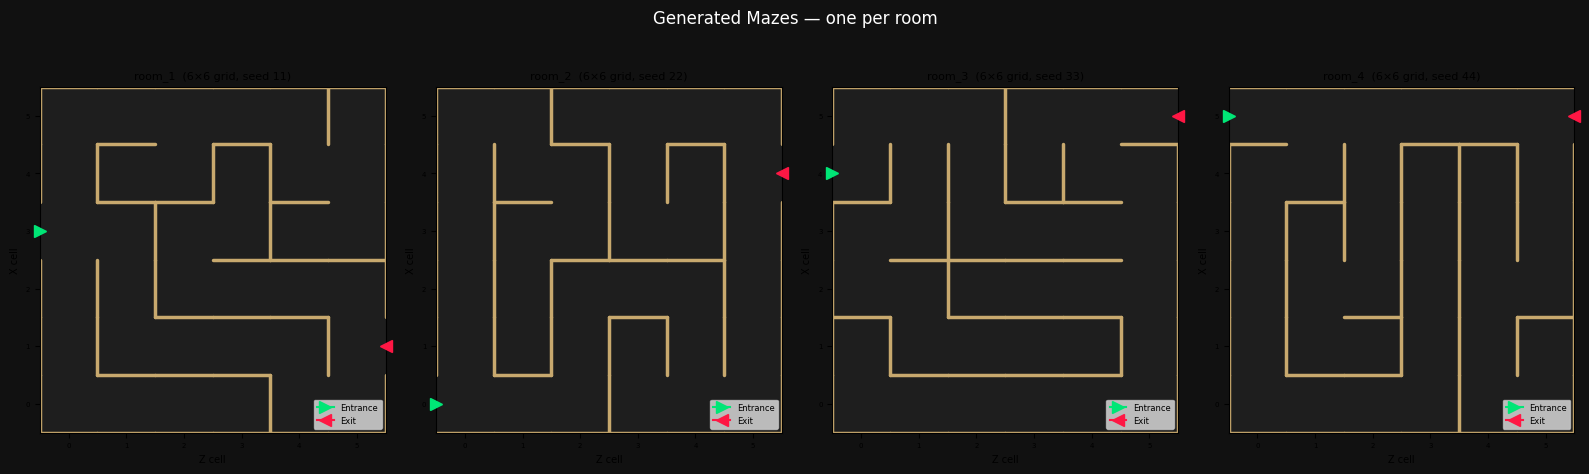

In [5]:
WALL_COLOR  = '#c8a96e'   # warm stone colour
FLOOR_COLOR = '#1e1e1e'
ENTRY_COLOR = '#00E676'
EXIT_COLOR  = '#FF1744'


def draw_maze_ax(ax, maze: dict, room: dict, seed: int) -> None:
    """
    Draw one maze on *ax*.
    Axes convention: x = Z direction (right = higher Z), y = X direction (up = higher X).
    """
    nx = room['nx']
    nz = room['nz']
    h_walls = maze['h_walls']   # (nz+1) × nx
    v_walls = maze['v_walls']   # nz × (nx+1)

    ax.set_facecolor(FLOOR_COLOR)
    ax.set_xlim(-0.5, nz - 0.5)
    ax.set_ylim(-0.5, nx - 0.5)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=6)
    ax.set_xticks(range(nz))
    ax.set_yticks(range(nx))
    ax.set_xticklabels([str(i) for i in range(nz)], fontsize=5)
    ax.set_yticklabels([str(j) for j in range(nx)], fontsize=5)
    ax.set_xlabel('Z cell', fontsize=7)
    ax.set_ylabel('X cell', fontsize=7)
    ax.set_title(f"{room['id']}  ({nz}×{nx} grid, seed {seed})", fontsize=8)

    lw = 2.5

    # h_walls[i, j]: south (low-Z) border of cell (i, j)
    # In plot coords: vertical segment at x = i−0.5, from y = j−0.5 to j+0.5
    for i in range(nz + 1):
        for j in range(nx):
            if h_walls[i, j]:
                ax.plot([i - 0.5, i - 0.5], [j - 0.5, j + 0.5],
                        color=WALL_COLOR, lw=lw, solid_capstyle='round', zorder=2)

    # v_walls[i, j]: west (low-X) border of cell (i, j)
    # In plot coords: horizontal segment at y = j−0.5, from x = i−0.5 to i+0.5
    for i in range(nz):
        for j in range(nx + 1):
            if v_walls[i, j]:
                ax.plot([i - 0.5, i + 0.5], [j - 0.5, j - 0.5],
                        color=WALL_COLOR, lw=lw, solid_capstyle='round', zorder=2)

    # Entrance gap marker (south edge of row 0  →  x = −0.5)
    ec = maze['entrance_col']
    ax.plot(-0.5, ec, marker='>', color=ENTRY_COLOR, ms=8,
            zorder=5, clip_on=False, label='Entrance')

    # Exit gap marker (north edge of row nz−1  →  x = nz−0.5)
    xc = maze['exit_col']
    ax.plot(nz - 0.5, xc, marker='<', color=EXIT_COLOR, ms=8,
            zorder=5, clip_on=False, label='Exit')

    ax.legend(loc='lower right', fontsize=6, framealpha=0.7)


fig, axes = plt.subplots(1, len(rooms), figsize=(4 * len(rooms), 4.5),
                         facecolor='#111111')
if len(rooms) == 1:
    axes = [axes]

for ax, room in zip(axes, rooms):
    draw_maze_ax(ax, mazes[room['id']], room, SEEDS.get(room['id'], 0))

fig.suptitle('Generated Mazes — one per room', color='white', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / 'mazes.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

## Export `data/mazes.json`

Each room entry contains:
- `grid_nx`, `grid_nz` — cell counts
- `cell_width`, `cell_length` — metres per cell (X / Z)
- `entrance_col`, `exit_col` — which column has the gap
- `walls` — list of wall placements in **room-local world coordinates** (origin = room centre)
  - `x`, `z` — wall segment centre in metres
  - `rotation_y` — 0° for Z-facing walls, 90° for X-facing walls
  - `axis` — `'h'` (runs along X) or `'v'` (runs along Z)

In [9]:
def maze_to_export(maze: dict, room: dict, seed: int) -> dict:
    nx  = room['nx']
    nz  = room['nz']
    cw  = room['cell_width']    # metres per X cell
    cl  = room['cell_length']   # metres per Z cell
    hw  = room['width']  / 2    # half-width in X
    hl  = room['length'] / 2    # half-length in Z

    h_walls = maze['h_walls']   # (nz+1) × nx
    v_walls = maze['v_walls']   # nz × (nx+1)

    walls = []

    # h_walls[i, j]: runs along X at Z = i*cl - hl
    # centre: X = (j + 0.5)*cw - hw,  Z = i*cl - hl
    for i in range(nz + 1):
        for j in range(nx):
            if h_walls[i, j]:
                walls.append({
                    'x':          round((j + 0.5) * cw - hw, 4),
                    'z':          round(i          * cl - hl, 4),
                    'rotation_y': 0,
                    'axis':       'h',
                })

    # v_walls[i, j]: runs along Z at X = j*cw - hw
    # centre: X = j*cw - hw,  Z = (i + 0.5)*cl - hl
    for i in range(nz):
        for j in range(nx + 1):
            if v_walls[i, j]:
                walls.append({
                    'x':          round(j          * cw - hw, 4),
                    'z':          round((i + 0.5) * cl - hl, 4),
                    'rotation_y': 90,
                    'axis':       'v',
                })

    return {
        'room_id':      room['id'],
        'seed':         seed,
        'grid_nx':      nx,
        'grid_nz':      nz,
        'cell_width':   round(cw, 4),
        'cell_length':  round(cl, 4),
        'entrance_col': int(maze['entrance_col']),
        'exit_col':     int(maze['exit_col']),
        'walls':        walls,
    }


export = {
    'wall_segment': cam['wall_segment'],
    'mazes': [
        maze_to_export(mazes[r['id']], r, SEEDS.get(r['id'], 0))
        for r in rooms
    ],
}

out_path = DATA_DIR / 'mazes.json'
out_path.write_text(json.dumps(export, indent=2))
print(f'Saved → {out_path}')
for m in export['mazes']:
    print(f"  {m['room_id']:8s}  grid {m['grid_nz']}×{m['grid_nx']}  {len(m['walls'])} walls")

Saved → F:\Unity\Projects\DreamGuard\data\mazes.json
  room_1    grid 6×6  47 walls
  room_2    grid 6×6  47 walls
  room_3    grid 6×6  47 walls
  room_4    grid 6×6  47 walls
